# So sánh 4 mô hình — chọn model tốt nhất cho từng KPI

Đọc 4 file `*_per_kpi_config.json` (RL Z-score, ARIMA, STL, Isolation Forest), so sánh **AP** và **F1 (PW/PA)** theo từng KPI, chọn **model tốt nhất mỗi KPI**, và vẽ biểu đồ.

- **AP** = Average Precision trên test (diện tích PR-curve, không phụ thuộc ngưỡng) — **số chính**.
- **PW-F1 / PA-F1** = F1 point-wise / point-adjust (ngưỡng tune trên val).
- **IF** có 2 route (feature/shingle) → lấy route có AP cao hơn, F1 lấy cùng route.

> Cần đủ 4 file JSON — chạy các notebook model (kể cả `RL_Zscore` để sinh `rl_per_kpi_config.json`) trước.

In [1]:
import os
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

def find_root(marker='Data/train.csv'):
    for d in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
        if (d / marker).exists():
            return d
    raise FileNotFoundError('Không thấy repo root')
ROOT = find_root()

cfg = {'RL':    ROOT / 'Modeling' / 'Stats' / 'RL' / 'rl_per_kpi_config.json',
       'ARIMA': ROOT / 'Modeling' / 'Stats' / 'ARIMA' / 'arima_per_kpi_config.json',
       'STL':   ROOT / 'Modeling' / 'Stats' / 'STL' / 'stl_per_kpi_config.json',
       'IF':    ROOT / 'Modeling' / 'ML' / 'IsolationForest' / 'if_per_kpi_config.json'}
for name, pth in cfg.items():
    print(('CÓ   ' if os.path.exists(pth) else 'THIẾU'), name, '->', pth.name)

rl    = pd.read_json(cfg['RL'])
arima = pd.read_json(cfg['ARIMA'])
stl   = pd.read_json(cfg['STL'])
iff   = pd.read_json(cfg['IF'])
MODELS = ['RL', 'ARIMA', 'STL', 'IF']

CÓ    RL -> rl_per_kpi_config.json
CÓ    ARIMA -> arima_per_kpi_config.json
CÓ    STL -> stl_per_kpi_config.json
CÓ    IF -> if_per_kpi_config.json


## Chuẩn hoá 4 config về một khung chung

Mỗi model → cột `<M>_AP`, `<M>_PWF1`, `<M>_PAF1`, `<M>_param`. Với IF chọn route (feat/shingle) có AP cao hơn.

In [2]:
rl_s = pd.DataFrame({'kpi': rl.kpi, 'RL_AP': rl.ap_test,
                     'RL_PWF1': rl.f1_pw, 'RL_PAF1': rl.f1_pa,
                     'RL_param': rl.window.map(lambda w: f'w={w}')})
ar_s = pd.DataFrame({'kpi': arima.kpi, 'ARIMA_AP': arima.AP,
                     'ARIMA_PWF1': arima.PW_F1, 'ARIMA_PAF1': arima.PA_F1,
                     'ARIMA_param': arima.order.astype(str)})
st_s = pd.DataFrame({'kpi': stl.kpi, 'STL_AP': stl.AP,
                     'STL_PWF1': stl.PW_F1, 'STL_PAF1': stl.PA_F1,
                     'STL_param': stl.period.map(lambda p: f'period={p}')})
# IF: chọn route AP cao hơn, F1 lấy CÙNG route đó
route = np.where(iff.b_AP >= iff.a_AP, 'feat', 'shingle')
if_s = pd.DataFrame({'kpi': iff.kpi,
                     'IF_AP':   np.maximum(iff.a_AP, iff.b_AP),
                     'IF_PWF1': np.where(route == 'feat', iff.b_PW_F1, iff.a_PW_F1),
                     'IF_PAF1': np.where(route == 'feat', iff.b_PA_F1, iff.a_PA_F1),
                     'IF_param': [f'feat(n={nf})' if r == 'feat' else f'shingle(S={s},ms={ms})'
                                  for r, nf, s, ms in zip(route, iff.b_n_feat, iff.a_shingle, iff.a_max_samples)]})

df = (rl_s.merge(ar_s, on='kpi', how='outer')
          .merge(st_s, on='kpi', how='outer')
          .merge(if_s, on='kpi', how='outer'))

ap_cols = [f'{m}_AP' for m in MODELS]
par_col = {m: f'{m}_param' for m in MODELS}
df['best_model'] = df[ap_cols].idxmax(axis=1).str.replace('_AP', '', regex=False)
df['best_AP']    = df[ap_cols].max(axis=1)
df['best_param'] = df.apply(lambda r: r[par_col[r['best_model']]], axis=1)
df = df.sort_values('best_AP', ascending=False).reset_index(drop=True)
print('Số KPI so sánh:', len(df), '| Model vô địch:', df['best_model'].value_counts().to_dict())

Số KPI so sánh: 18 | Model vô địch: {'IF': 9, 'ARIMA': 8, 'STL': 1}


## Bảng AP theo KPI + model thắng

In [3]:
macro_ap = {m: round(float(df[f'{m}_AP'].mean()), 3) for m in MODELS}
print('MACRO AP :', macro_ap)
print('KPI thắng:', df['best_model'].value_counts().to_dict())
df[['kpi'] + ap_cols + ['best_model', 'best_AP', 'best_param']].round(3)

MACRO AP : {'RL': 0.153, 'ARIMA': 0.381, 'STL': 0.28, 'IF': 0.512}
KPI thắng: {'IF': 9, 'ARIMA': 8, 'STL': 1}


,kpi,RL_AP,ARIMA_AP,STL_AP,IF_AP,best_model,best_AP,best_param
0,1c35dbf5,0.113,0.292,0.282,0.979,IF,0.979,feat(n=25)
1,9ee58794,0.058,0.855,0.755,0.906,IF,0.906,feat(n=14)
2,02e99bd4,0.075,0.473,0.468,0.898,IF,0.898,feat(n=19)
3,e0770391,0.084,0.292,0.151,0.874,IF,0.874,"shingle(S=16,ms=256)"
4,8c892e55,0.084,0.194,0.151,0.861,IF,0.861,"shingle(S=8,ms=512)"
5,da403e4e,0.084,0.752,0.690,0.829,IF,0.829,feat(n=21)
6,a40b1df8,0.424,0.722,0.433,0.628,ARIMA,0.722,"(2,0,2)"
7,7c189dd3,0.435,0.699,0.502,0.617,ARIMA,0.699,"(2,0,2)"
8,18fbb1d5,0.081,0.485,0.167,0.636,IF,0.636,feat(n=23)
9,affb01ca,0.409,0.615,0.383,0.538,ARIMA,0.615,"(2,0,2)"


## Bảng F1 theo KPI (PW = point-wise, PA = point-adjust)

Lưu ý: thứ hạng theo F1 **khác** theo AP — nhất là PA-F1 (xem kết luận).

In [4]:
from IPython.display import display
pw_cols = [f'{m}_PWF1' for m in MODELS]
pa_cols = [f'{m}_PAF1' for m in MODELS]
print('MACRO PW-F1:', {m: round(float(df[f'{m}_PWF1'].mean()), 3) for m in MODELS})
print('MACRO PA-F1:', {m: round(float(df[f'{m}_PAF1'].mean()), 3) for m in MODELS})
print('\n— F1 point-wise (PW) —')
display(df[['kpi'] + pw_cols].round(3))
print('— F1 point-adjust (PA) —')
df[['kpi'] + pa_cols].round(3)

MACRO PW-F1: {'RL': 0.172, 'ARIMA': 0.312, 'STL': 0.227, 'IF': 0.333}
MACRO PA-F1: {'RL': 0.531, 'ARIMA': 0.485, 'STL': 0.325, 'IF': 0.442}

— F1 point-wise (PW) —


,kpi,RL_PWF1,ARIMA_PWF1,STL_PWF1,IF_PWF1
0,1c35dbf5,0.190,0.334,0.334,0.768
1,9ee58794,0.051,0.776,0.470,0.701
2,02e99bd4,0.110,0.482,0.434,0.754
3,e0770391,0.032,0.117,0.044,0.000
4,8c892e55,0.030,0.121,0.043,0.000
5,da403e4e,0.018,0.121,0.109,0.339
6,a40b1df8,0.504,0.744,0.466,0.580
7,7c189dd3,0.511,0.704,0.587,0.542
8,18fbb1d5,0.004,0.004,0.004,0.255
9,affb01ca,0.466,0.615,0.412,0.512


— F1 point-adjust (PA) —


,kpi,RL_PAF1,ARIMA_PAF1,STL_PAF1,IF_PAF1
0,1c35dbf5,0.010,0.023,0.000,0.998
1,9ee58794,0.935,0.951,0.492,0.643
2,02e99bd4,0.947,0.963,0.827,0.991
3,e0770391,0.955,0.620,0.083,0.000
4,8c892e55,0.950,0.604,0.081,0.000
5,da403e4e,0.764,0.981,0.886,0.932
6,a40b1df8,0.438,0.462,0.551,0.455
7,7c189dd3,0.421,0.423,0.333,0.403
8,18fbb1d5,0.296,0.261,0.269,0.784
9,affb01ca,0.443,0.386,0.316,0.347


## Biểu đồ AP per-KPI + macro

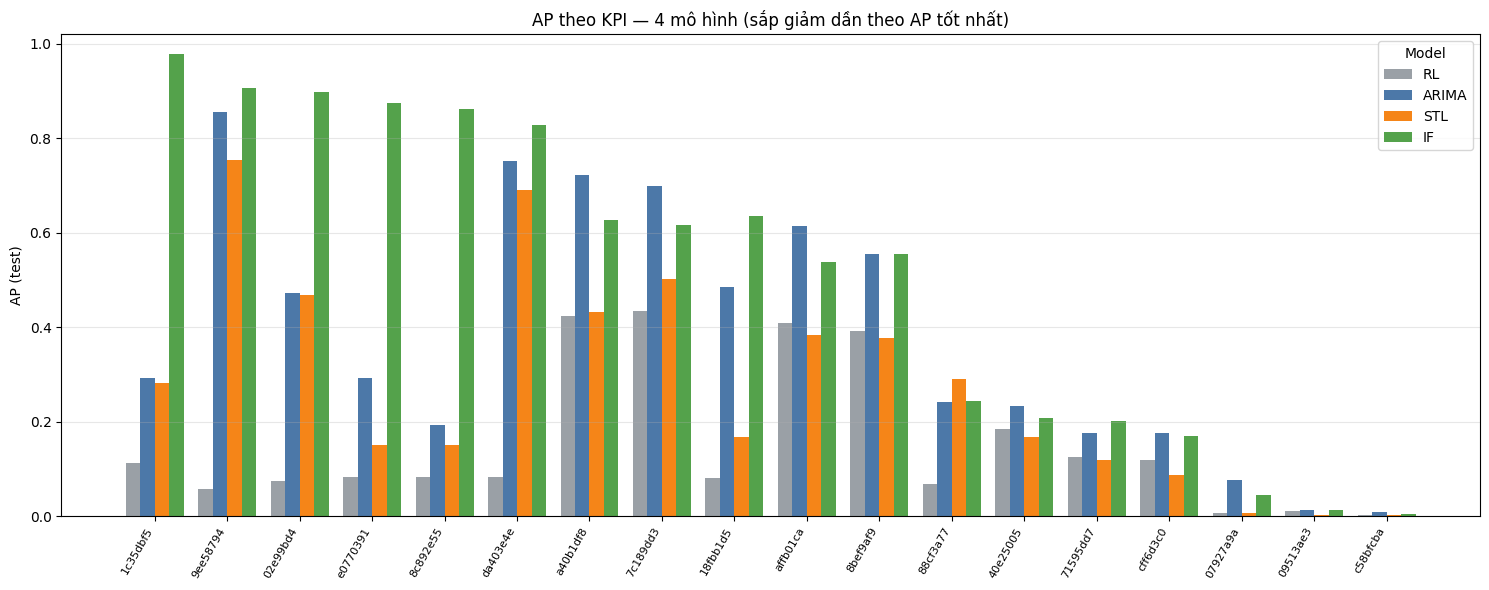

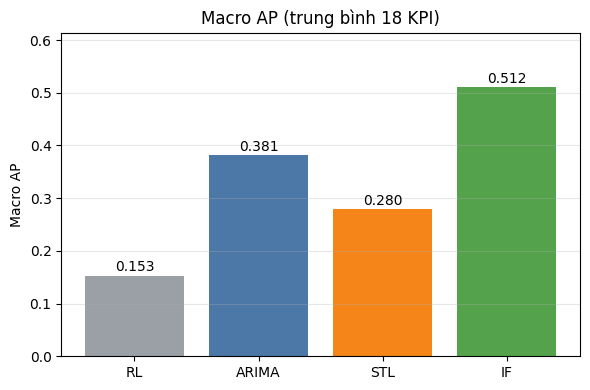

In [5]:
colors = {'RL': '#9aa0a6', 'ARIMA': '#4c78a8', 'STL': '#f58518', 'IF': '#54a24b'}
macro_ap = {m: float(df[f'{m}_AP'].mean()) for m in MODELS}

# (1) AP theo KPI — cột nhóm
d = df.sort_values('best_AP', ascending=False)
x = np.arange(len(d)); w = 0.2
fig, ax = plt.subplots(figsize=(15, 6))
for i, m in enumerate(MODELS):
    ax.bar(x + (i - 1.5) * w, d[f'{m}_AP'].values, w, label=m, color=colors[m])
ax.set_xticks(x); ax.set_xticklabels(d['kpi'].values, rotation=60, ha='right', fontsize=8)
ax.set_ylabel('AP (test)'); ax.set_ylim(0, 1.02)
ax.set_title('AP theo KPI — 4 mô hình (sắp giảm dần theo AP tốt nhất)')
ax.legend(title='Model'); ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

# (2) Macro AP — 4 cột
fig, ax = plt.subplots(figsize=(6, 4))
vals = [macro_ap[m] for m in MODELS]
ax.bar(MODELS, vals, color=[colors[m] for m in MODELS])
for i, v in enumerate(vals):
    ax.text(i, v + 0.008, f'{v:.3f}', ha='center', fontsize=10)
ax.set_ylabel('Macro AP'); ax.set_ylim(0, max(vals) * 1.2)
ax.set_title('Macro AP (trung bình 18 KPI)'); ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

## Kết luận

**1. Xếp hạng theo AP (số chính):** IF **0.51** > ARIMA **0.38** > STL **0.28** > RL **0.15**. Số KPI vô địch: **IF 9 · ARIMA 8 · STL 1 · RL 0**.

**2. Đổi metric → đổi thứ hạng (rất quan trọng khi báo cáo):**
- **PW-F1** (khắt khe, từng điểm): IF 0.333 > ARIMA 0.312 > STL 0.227 > RL 0.172 — gần thứ tự AP.
- **PA-F1** (point-adjust): **RL 0.531 > ARIMA 0.485 > IF 0.442 > STL 0.325** — baseline Z-score LẠI đứng đầu! Vì point-adjust chỉ cần bắt ≥1 điểm/đoạn ⇒ Z-score bắt spike tốt → recall cao. → **PA-F1 dễ thổi phồng detector đơn giản**; nên lấy **AP làm số chính**, đọc PA-F1 thận trọng.

**3. Không model nào thắng tất cả** → chọn model theo từng KPI (bảng trên): IF cho KPI tín hiệu mạnh/nhiều feature, ARIMA cho KPI tự tương quan vừa + tín hiệu yếu, STL/RL hiếm khi tối ưu.

**4. Caveat:** `IF_AP`/`IF_*F1` lấy theo route (feat/shingle) có AP test cao hơn — kịch bản tốt nhất của IF (chặt chẽ thì chọn route theo val). RL chạy trên `value` thô (không reindex). AP giữa các model có sai số nhỏ do tập điểm hợp lệ khác nhau (STL bỏ segment ngắn, IF/ARIMA bỏ warm-up).